EROSION

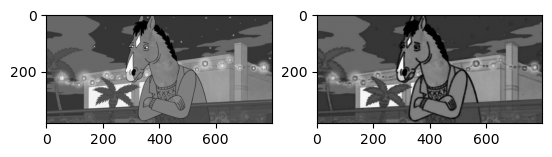

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('IMG.jpeg',cv2.IMREAD_GRAYSCALE)

#ELEMENTO ESTRUCTURANTE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar erosion
img_rest=cv2.erode(imagen,kernel)
plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.subplot(122)
plt.imshow(img_rest, cmap='gray')

erosion binaria

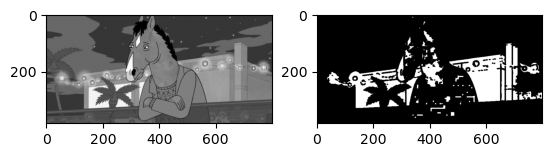

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('IMG.jpeg',cv2.IMREAD_GRAYSCALE)
_,img_bin=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
#ELEMENTO ESTRUCTURANTE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar erosion
img_rest=cv2.erode(img_bin,kernel)
plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.subplot(122)
plt.imshow(img_rest, cmap='gray')

DILATACIÓN

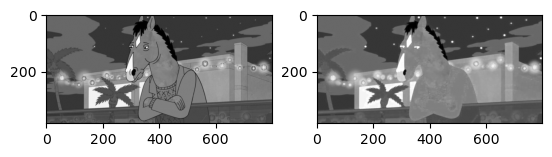

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('IMG.jpeg',cv2.IMREAD_GRAYSCALE)

#ELEMENTO ESTRUCTURANTE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar erosion
img_rest=cv2.dilate(imagen,kernel)
plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.subplot(122)
plt.imshow(img_rest, cmap='gray')

Dilatación Binaria

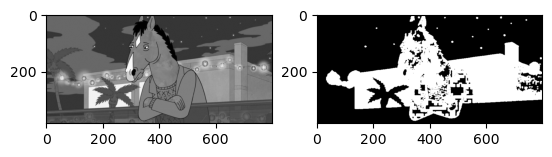

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('IMG.jpeg',cv2.IMREAD_GRAYSCALE)
_,img_bin=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
#ELEMENTO ESTRUCTURANTE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar erosion
img_rest=cv2.dilate(img_bin,kernel)
plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.subplot(122)
plt.imshow(img_rest, cmap='gray')

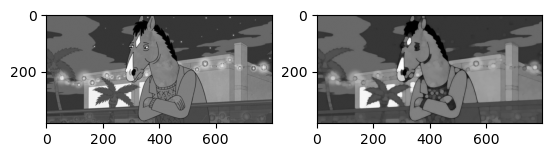

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('IMG.jpeg',cv2.IMREAD_GRAYSCALE)

#ELEMENTO ESTRUCTURANTE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))
#aplicar erosion
#img_rest=cv2.dilate(imagen,kernel)
apertura=cv2.morphologyEx(imagen,cv2.MORPH_OPEN,kernel)
plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.subplot(122)
plt.imshow(apertura, cmap='gray')

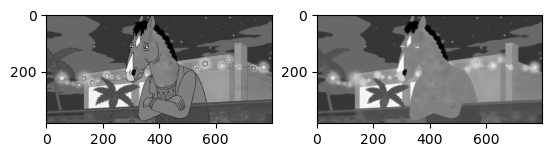

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('IMG.jpeg',cv2.IMREAD_GRAYSCALE)

#ELEMENTO ESTRUCTURANTE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))
#aplicar erosion
#img_rest=cv2.dilate(imagen,kernel)
apertura=cv2.morphologyEx(imagen,cv2.MORPH_CLOSE,kernel)
plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.subplot(122)
plt.imshow(apertura, cmap='gray')

##SKIMAGE=>MORPHOLOGY.BINARY_OPENING

UTILIZAR SKIMAGE CON EROSIÓN, DILATACIÓN, APERTURA Y CERRADURA

skimage.morphology.ball
skimage.morphology.binary_closing
skimage.morphology.binary_dilation

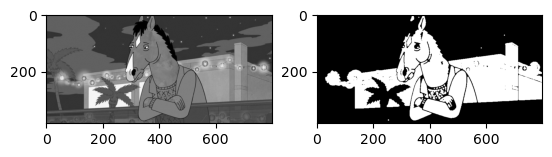

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu
from skimage.morphology import binary_opening, disk

imagen = io.imread('IMG.jpeg', as_gray=True)
umbral = threshold_otsu(imagen)

imagen_binaria = imagen > umbral
kernel = disk(2)

img_rest = binary_opening(imagen_binaria, kernel)

plt.subplot(121)
plt.imshow(imagen, cmap='gray')

plt.subplot(122)
plt.imshow(img_rest, cmap='gray')
plt.show()


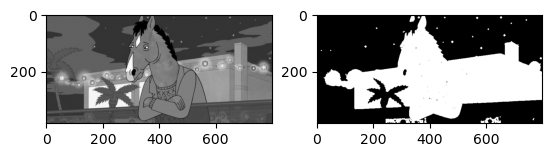

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu
from skimage.morphology import binary_dilation

imagen = io.imread('IMG.jpeg', as_gray=True)
umbral = threshold_otsu(imagen)

imagen_binaria = imagen > umbral
kernel = disk(2)

img_rest = binary_dilation(imagen_binaria, kernel)

plt.subplot(121)
plt.imshow(imagen, cmap='gray')

plt.subplot(122)
plt.imshow(img_rest, cmap='gray')
plt.show()


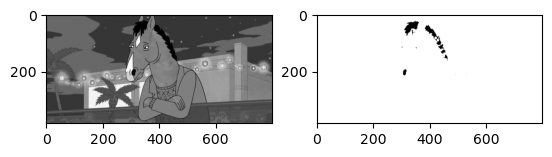

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import binary_opening
imagen=cv2.imread('IMG.jpeg',cv2.IMREAD_GRAYSCALE)

#ELEMENTO ESTRUCTURANTE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar erosion
img_rest=binary_opening(imagen,kernel)
plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.subplot(122)
plt.imshow(img_rest, cmap='gray')

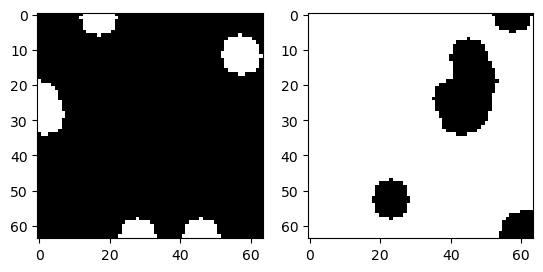

In [7]:
from skimage import data, morphology
import matplotlib.pyplot as plt
image=data.binary_blobs(length=64,n_dim=2)
kernel=morphology.disk(5)
apertura=morphology.binary_opening(image,kernel)
cerradura=morphology.binary_closing(image,kernel)
plt.subplot(121)
plt.imshow(apertura, cmap='gray')
plt.subplot(122)
plt.imshow(cerradura, cmap='gray')

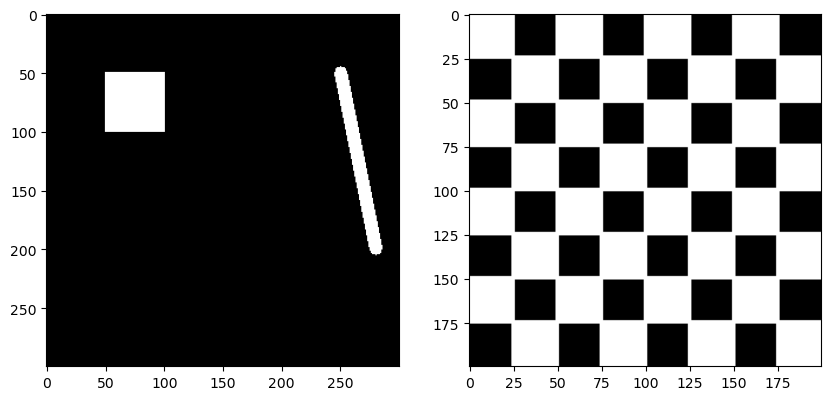

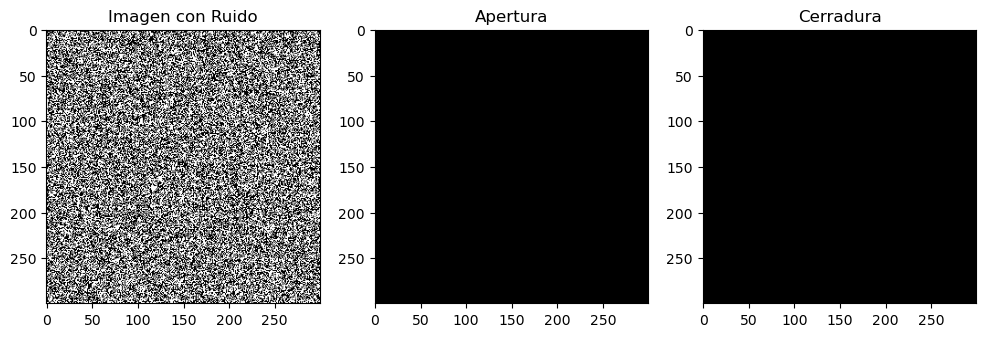

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import checkerboard

image=np.zeros((300,300),dtype=np.uint8)
image=cv2.circle(image,(200,100),255,-1)
image=cv2.rectangle(image,(50,50),(100,100),255,-1)
image=cv2.line(image,(250,50),(280,200),255,10)

cheker=checkerboard()>0.5
cheker=cheker.astype(np.uint8)*255
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.subplot(122)
plt.imshow(cheker, cmap='gray')

kernel_ellipse=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
kernel_cross=cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5))
kernel_rect=cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))

#APLICANDO
erode_cross=cv2.erode(image,kernel_cross,iterations=1)
dilate_cross=cv2.dilate(image,kernel_cross,iterations=1)

erode_rect=cv2.erode(image,kernel_rect,iterations=1)
dilate_rect=cv2.dilate(image,kernel_rect,iterations=1)

erode_ellipse=cv2.erode(image,kernel_ellipse,iterations=1)
dilate_ellipse=cv2.dilate(image,kernel_ellipse,iterations=1)

erode_cheker=cv2.erode(cheker,kernel_ellipse,iterations=1)
dilate_cheker=cv2.dilate(cheker,kernel_ellipse,iterations=1)

#creamos imagen apertura y cerradura
np.random.seed(42)
imagen_ruido=image.copy()
ruido = np.random.randint(0, 2, size=image.shape, dtype=np.uint8) * 255
imagen_ruido=cv2.bitwise_xor(imagen_ruido,ruido)

apertura=cv2.morphologyEx(imagen_ruido,cv2.MORPH_OPEN,kernel_rect)
cerradura=cv2.morphologyEx(imagen_ruido,cv2.MORPH_CLOSE,kernel_rect)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.title('Imagen con Ruido')
plt.imshow(imagen_ruido, cmap='gray')
plt.subplot(132)
plt.title('Apertura')
plt.imshow(apertura, cmap='gray')
plt.subplot(133)
plt.title('Cerradura')
plt.imshow(cerradura, cmap='gray')
plt.show()

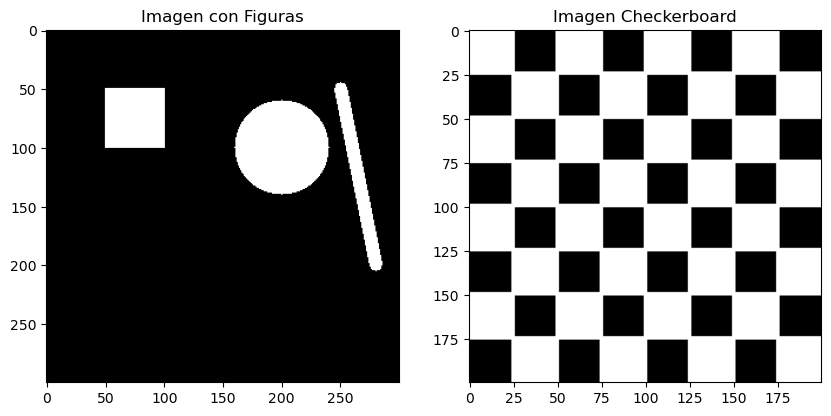

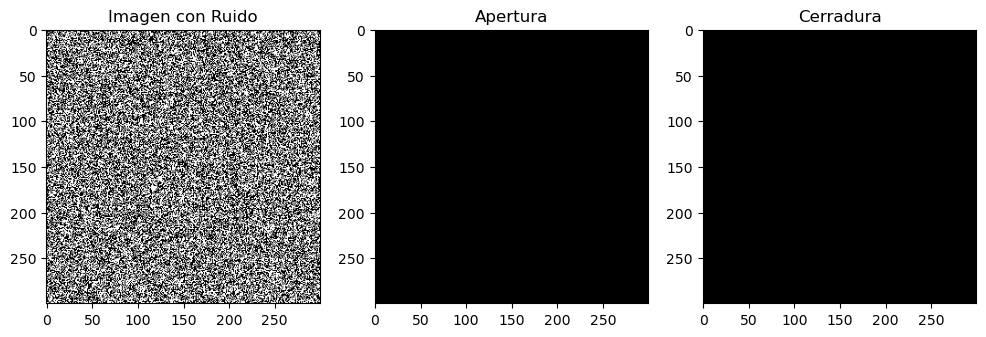

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import checkerboard

image = np.zeros((300, 300), dtype=np.uint8)
image = cv2.circle(image, (200, 100), 40, 255, -1)
image = cv2.rectangle(image, (50, 50), (100, 100), 255, -1)
image = cv2.line(image, (250, 50), (280, 200), 255, 10)

cheker = checkerboard() > 0.5
cheker = cheker.astype(np.uint8) * 255

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title('Imagen con Figuras')
plt.imshow(image, cmap='gray')
plt.subplot(122)
plt.title('Imagen Checkerboard')
plt.imshow(cheker, cmap='gray')
plt.show()

kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

erode_cross = cv2.erode(image, kernel_cross, iterations=1)
dilate_cross = cv2.dilate(image, kernel_cross, iterations=1)

erode_rect = cv2.erode(image, kernel_rect, iterations=1)
dilate_rect = cv2.dilate(image, kernel_rect, iterations=1)

erode_ellipse = cv2.erode(image, kernel_ellipse, iterations=1)
dilate_ellipse = cv2.dilate(image, kernel_ellipse, iterations=1)

erode_cheker = cv2.erode(cheker, kernel_ellipse, iterations=1)
dilate_cheker = cv2.dilate(cheker, kernel_ellipse, iterations=1)

np.random.seed(42)
imagen_ruido = image.copy()
ruido = np.random.randint(0, 2, size=image.shape, dtype=np.uint8) * 255
imagen_ruido = cv2.bitwise_xor(imagen_ruido, ruido)

apertura = cv2.morphologyEx(imagen_ruido, cv2.MORPH_OPEN, kernel_rect)
cerradura = cv2.morphologyEx(imagen_ruido, cv2.MORPH_CLOSE, kernel_rect)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.title('Imagen con Ruido')
plt.imshow(imagen_ruido, cmap='gray')
plt.subplot(132)
plt.title('Apertura')
plt.imshow(apertura, cmap='gray')
plt.subplot(133)
plt.title('Cerradura')
plt.imshow(cerradura, cmap='gray')
plt.show()


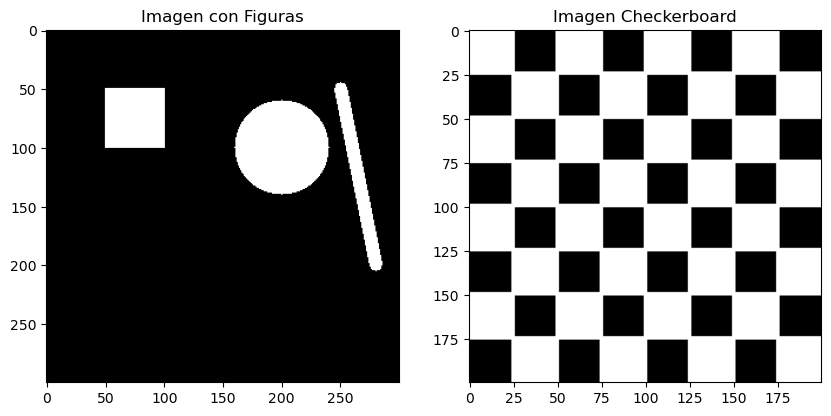

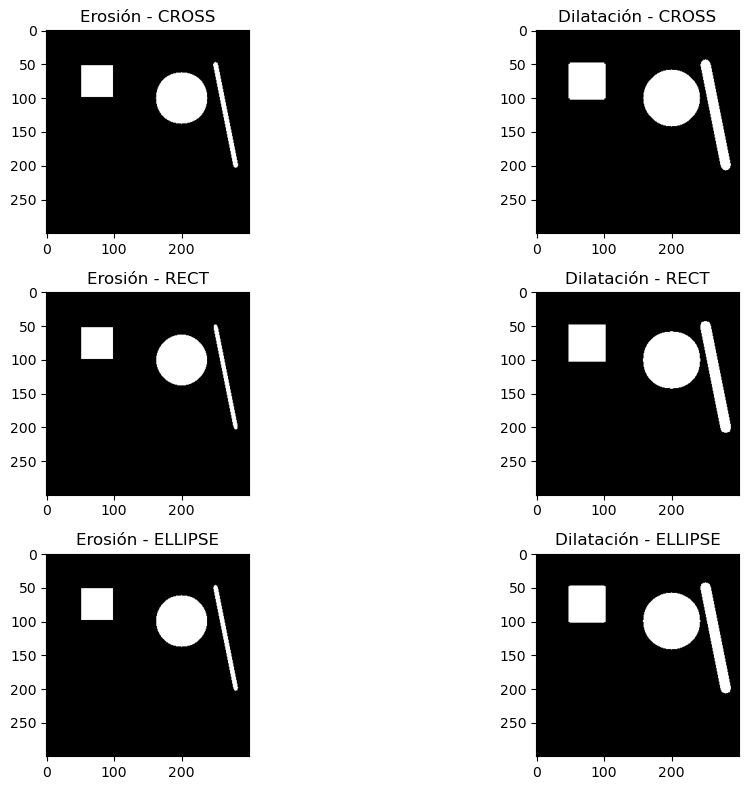

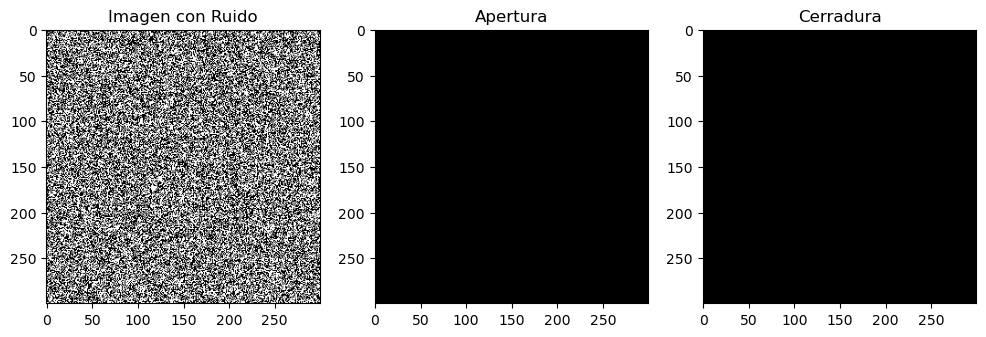

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import checkerboard

image = np.zeros((300, 300), dtype=np.uint8)
image = cv2.circle(image, (200, 100), 40, 255, -1)
image = cv2.rectangle(image, (50, 50), (100, 100), 255, -1)
image = cv2.line(image, (250, 50), (280, 200), 255, 10)

cheker = checkerboard() > 0.5
cheker = cheker.astype(np.uint8) * 255

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title('Imagen con Figuras')
plt.imshow(image, cmap='gray')
plt.subplot(122)
plt.title('Imagen Checkerboard')
plt.imshow(cheker, cmap='gray')
plt.show()

kernels = {
    "CROSS": cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5)),
    "RECT": cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    "ELLIPSE": cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
}

plt.figure(figsize=(12, 8))
i = 1
for name, kernel in kernels.items():
    eroded = cv2.erode(image, kernel, iterations=1)
    dilated = cv2.dilate(image, kernel, iterations=1)
    
    plt.subplot(3, 2, i)
    plt.title(f'Erosión - {name}')
    plt.imshow(eroded, cmap='gray')
    i += 1
    
    plt.subplot(3, 2, i)
    plt.title(f'Dilatación - {name}')
    plt.imshow(dilated, cmap='gray')
    i += 1

plt.tight_layout()
plt.show()

np.random.seed(42)
imagen_ruido = image.copy()
ruido = np.random.randint(0, 2, size=image.shape, dtype=np.uint8) * 255
imagen_ruido = cv2.bitwise_xor(imagen_ruido, ruido)

apertura = cv2.morphologyEx(imagen_ruido, cv2.MORPH_OPEN, kernels["RECT"])
cerradura = cv2.morphologyEx(imagen_ruido, cv2.MORPH_CLOSE, kernels["RECT"])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Imagen con Ruido')
plt.imshow(imagen_ruido, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Apertura')
plt.imshow(apertura, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Cerradura')
plt.imshow(cerradura, cmap='gray')
plt.show()
